<img src="images/arm_logo.png" width=500 alt="ARM Logo"></img>

# Training of Neural Net with Long Short-Term Memory

In [ ]:
# load imports
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import copy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
# load data with xarray
ds_radio = xr.open_dataset('radiometer.nc')
ds_radio = ds_radio[['vap', 'qc_vap', 'liq','qc_liq']]
ds_cbh = xr.open_dataset('cbh_ceil.nc')

ds_mfrs = xr.open_mfdataset('sgpmfrsr7nchC1.b1/*')
ds_mfrs = ds_mfrs[['computed_cosine_correction_filter6', 'direct_normal_narrowband_filter6',
                'qc_direct_normal_narrowband_filter6']]
ds_mfrs

/tmp/ipykernel_645855/2614269791.py:6: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_mfrs = xr.open_mfdataset('sgpmfrsr7nchC1.b1/*')


<xarray.Dataset> Size: 31MB
Dimensions:                              (time: 1573879)
Coordinates:
  * time                                 (time) datetime64[ns] 13MB 2025-01-0...
Data variables:
    computed_cosine_correction_filter6   (time) float32 6MB dask.array<chunksize=(4320,), meta=np.ndarray>
    direct_normal_narrowband_filter6     (time) float32 6MB dask.array<chunksize=(4320,), meta=np.ndarray>
    qc_direct_normal_narrowband_filter6  (time) int32 6MB dask.array<chunksize=(4320,), meta=np.ndarray>
Attributes: (12/34)
    command_line:                mfrsr7nch_ingest -s sgp -f C1
    Conventions:                 ARM-1.2
    process_version:             ingest-mfrsr7nch-1.8-0.el7
    dod_version:                 mfrsr7nch-b1-1.1
    input_source:                /data/collection/sgp/sgpmfrsr7nchC1.00/MFRSR...
    site_id:                     sgp
    ...                          ...
    qc_bit_2_description:        Value is less than the valid_min.
    qc_bit_2_assessment:         Bad
    qc_bit_3_description:        Value is greater than the valid_max.
    qc_bit_3_assessment:         Bad
    doi:                         10.5439/1429369
    history:                     created by user dsmgr on machine prod-proc3....

In [ ]:
ds_mfrs = ds_mfrs.compute()

# remove data where the value of the QC bit is not 0 (remove the bad data)
ds_mfrs = ds_mfrs.where(ds_mfrs.qc_direct_normal_narrowband_filter6 == 0, drop=True)
ds_mfrs = ds_mfrs.where(ds_mfrs.direct_normal_narrowband_filter6 > 0.15, drop=True)
ds_radio = ds_radio.where(ds_radio.qc_vap == 0, drop=True)
ds_cbh = ds_cbh.where(ds_cbh.qc_first_cbh == 0, drop=True)
ds_cbh = ds_cbh.where(ds_cbh.first_cbh >= 5000, drop=True)

In [ ]:
# 1. Round or floor the time coordinates to the 1-minute mark ('min')
ds_radio_rounded = ds_radio.assign_coords(time=ds_radio.time.dt.floor("min"))
ds_mfrs_rounded = ds_mfrs.assign_coords(time=ds_mfrs.time.dt.floor("min"))
ds_cbh_rounded = ds_cbh.assign_coords(time=ds_cbh.time.dt.floor("min"))

# 2. If flooring introduces duplicate timestamps within the same dataset, clean them up:
ds_radio_rounded = ds_radio_rounded.drop_duplicates("time")
ds_mfrs_rounded = ds_mfrs_rounded.drop_duplicates("time")
ds_cbh_rounded = ds_cbh_rounded.drop_duplicates("time")

# 3. Now your inner merge works smoothly
ds_merged = xr.merge(
    [ds_radio_rounded, ds_mfrs_rounded, ds_cbh_rounded], join="inner"
)
ds_merged

<xarray.Dataset> Size: 127kB
Dimensions:                              (time: 2121)
Coordinates:
  * time                                 (time) datetime64[ns] 17kB 2025-01-0...
Data variables:
    vap                                  (time) float32 8kB 1.083 ... 2.203
    qc_vap                               (time) float64 17kB 0.0 0.0 ... 0.0 0.0
    liq                                  (time) float32 8kB -0.0001 ... 0.0015
    qc_liq                               (time) float64 17kB 0.0 0.0 ... 0.0 0.0
    computed_cosine_correction_filter6   (time) float32 8kB 0.989 ... 0.9921
    direct_normal_narrowband_filter6     (time) float32 8kB 0.1904 ... 0.1602
    qc_direct_normal_narrowband_filter6  (time) float64 17kB 0.0 0.0 ... 0.0 0.0
    first_cbh                            (time) float32 8kB 7.62e+03 ... 5.48...
    qc_first_cbh                         (time) float64 17kB 0.0 0.0 ... 0.0 0.0
Attributes: (12/55)
    command_line:                       mwr_ingest -s sgp -f C1
    process_version:                    ingest-mwr-2.3-0.el7
    ingest_software:                    ingest-mwr-2.3-0.el7
    dod_version:                        mwrlos-b1-2.3
    site_id:                            sgp
    facility_id:                        C1: Lamont, Oklahoma
    ...                                 ...
    datastream:                         sgpmwrlosC1.b1
    history:                            created by user dsmgr on machine prod...
    _file_dates:                        ['20250101', '20250101', '20250102', ...
    _file_times:                        ['000000', '000040', '000020', '00000...
    _datastream:                        sgpmwrlosC1.b1
    _arm_standards_flag:                1

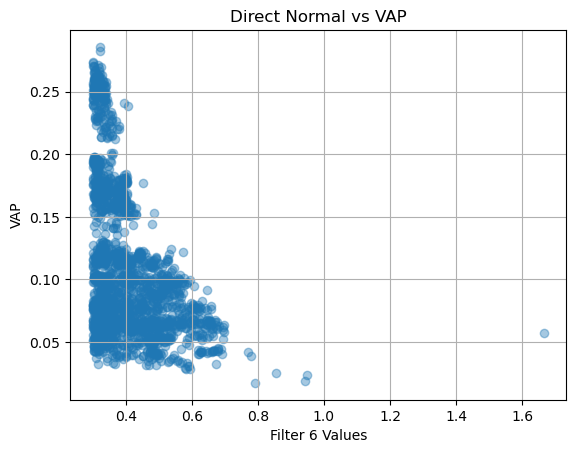

In [ ]:
plt.scatter(ds_merged.direct_normal_narrowband_filter6.values*2, ds_merged.vap.values/ds_merged.computed_cosine_correction_filter6.values*0.067, alpha=0.4)
plt.title("Direct Normal vs VAP")
plt.xlabel("Filter 6 Values")
plt.ylabel("VAP")
plt.grid(True)

In [ ]:
np.max(ds_merged.vap.values/ds_merged.computed_cosine_correction_filter6.values)

np.float32(4.2646008)

In [ ]:
# split the datasets into training, validation, and testing
x_data = ds_merged[['direct_normal_narrowband_filter6', 'computed_cosine_correction_filter6']].to_array().values.T
x_data = x_data
y_data = ds_merged.vap.values # / ds_merged.computed_cosine_correction_filter6.values *0.067

x_train = x_data[:int(x_data.shape[0]*0.8),:]
x_val = x_data[int(x_data.shape[0]*0.8):int(x_data.shape[0]*0.9),:]
x_test = x_data[int(x_data.shape[0]*0.9):,:]

y_train = y_data[:int(x_data.shape[0]*0.8)]
y_val = y_data[int(x_data.shape[0]*0.8):int(x_data.shape[0]*0.9)]
y_test = y_data[int(x_data.shape[0]*0.9):]

print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(1696, 2) (1696,)
(213, 2) (213,)


In [ ]:
# Target variables (y) must still be reshaped to (-1, 1) to match the output dimension
X_train_tensor = torch.tensor(x_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)

X_val_tensor = torch.tensor(x_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).reshape(-1, 1)

X_test_tensor = torch.tensor(x_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)

print("New Feature Shape:", X_train_tensor.shape)  # Should read: torch.Size([time, 3])
print("New Target Shape:", y_train_tensor.shape)    # Should read: torch.Size([time, 1])

# Rebuild your DataLoaders
BATCH_SIZE = 64
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=BATCH_SIZE, shuffle=False)

New Feature Shape: torch.Size([1696, 2])
New Target Shape: torch.Size([1696, 1])


In [ ]:
import torch.nn as nn
import torch.optim as optim

# =====================================================================
# SIMPLE 3-HIDDEN-LAYER NEURAL NETWORK
# =====================================================================
class SimpleRegressor(nn.Module):
    def __init__(self, input_dim):
        super(SimpleRegressor, self).__init__()
        
        # Pure linear connections without any extra regularization or normalization
        self.layer1 = nn.Linear(input_dim, 64)  # Input -> Hidden 1
        self.layer2 = nn.Linear(64, 32)         # Hidden 1 -> Hidden 2
        self.layer3 = nn.Linear(32, 16)         # Hidden 2 -> Hidden 3
        self.output = nn.Linear(16, 1)          # Hidden 3 -> 1 Final Prediction
        
        self.relu = nn.ReLU() # Standard activation function
        
    def forward(self, x):
        # Linearly combine, activate, repeat
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.relu(self.layer3(x))
        return self.output(x)

# 1. Initialize the simple network
input_features = X_train_tensor.shape[1] # Automatically reads your 3 input variables
model = SimpleRegressor(input_dim=input_features)

# 2. Standard Loss Function 
criterion = nn.MSELoss() 

# 3. Clean Adam Optimizer (no extra weight decay)
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
# --- EARLY STOPPING CONFIGURATION ---
NUM_EPOCHS = 100          # Raised this so early stopping actually has room to work!
patience = 10             # Number of epochs to wait for improvement before quitting
patience_counter = 0      # Tracks how many bad epochs in a row we've had
best_val_loss = float('inf') # Initialize at infinity so any real loss beats it
best_model_wts = copy.deepcopy(model.state_dict()) # To store our best weights

In [ ]:
for epoch in range(NUM_EPOCHS):
    model.train()
    running_train_loss = 0.0
    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)           
        loss = criterion(outputs, batch_y)  
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item() * batch_X.size(0)
        
    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    
    # --- VALIDATION PHASE ---
    model.eval()  
    running_val_loss = 0.0
    
    with torch.no_grad():  
        for batch_X, batch_y in val_loader:
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            running_val_loss += loss.item() * batch_X.size(0)
            
    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    
    print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")
    
    # --- EARLY STOPPING CHECK ---
    if epoch_val_loss < best_val_loss:
        # We found a better model! Reset counter and save the weights
        best_val_loss = epoch_val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        patience_counter = 0
        print(f"--> New best model found! Saving weights...")
    else:
        # No improvement, increase the penalty counter
        patience_counter += 1
        print(f"--> No improvement. Patience: {patience_counter}/{patience}")
        
        if patience_counter >= patience:
            print(f"\n🛑 Early stopping triggered! Stopping training at epoch {epoch+1}.")
            break

# =====================================================================
# RESTORE BEST MODEL WEIGHTS
# =====================================================================
print("Loading best model weights for final evaluation...")
model.load_state_dict(best_model_wts)

# =====================================================================
# 4. FINAL TESTING PHASE
# =====================================================================
model.eval()

total_absolute_error = 0.0  
all_preds = []
all_targets = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        predictions = model(batch_X)
        
        # 1. Accumulate absolute errors for MAE
        absolute_errors = torch.abs(predictions - batch_y)
        total_absolute_error += absolute_errors.sum().item()
        
        # 2. Append the batch values to our lists for R²
        all_preds.extend(predictions.cpu().numpy())
        all_targets.extend(batch_y.cpu().numpy())

average_mae = total_absolute_error / len(test_loader.dataset)
test_r2 = r2_score(all_targets, all_preds)

# Print your complete performance report
print(f"\n================ FINAL TEST PERFORMANCE ================")
print(f"Mean Absolute Error (MAE): {average_mae:.4f}")
print(f"R² Score (Variance Explained): {test_r2:.4f}")
print(f"========================================================")

Epoch 01/100 | Train Loss: 1.6455 | Val Loss: 5.4625
--> New best model found! Saving weights...
Epoch 02/100 | Train Loss: 0.7946 | Val Loss: 2.5191
--> New best model found! Saving weights...
Epoch 03/100 | Train Loss: 0.6700 | Val Loss: 3.0091
--> No improvement. Patience: 1/10
Epoch 04/100 | Train Loss: 0.6592 | Val Loss: 2.8470
--> No improvement. Patience: 2/10
Epoch 05/100 | Train Loss: 0.6558 | Val Loss: 2.8294
--> No improvement. Patience: 3/10
Epoch 06/100 | Train Loss: 0.6533 | Val Loss: 2.7398
--> No improvement. Patience: 4/10
Epoch 07/100 | Train Loss: 0.6511 | Val Loss: 2.9342
--> No improvement. Patience: 5/10
Epoch 08/100 | Train Loss: 0.6497 | Val Loss: 2.7840
--> No improvement. Patience: 6/10
Epoch 09/100 | Train Loss: 0.6456 | Val Loss: 2.7051
--> No improvement. Patience: 7/10
Epoch 10/100 | Train Loss: 0.6415 | Val Loss: 2.5917
--> No improvement. Patience: 8/10
Epoch 11/100 | Train Loss: 0.6379 | Val Loss: 2.8763
--> No improvement. Patience: 9/10
Epoch 12/100 |

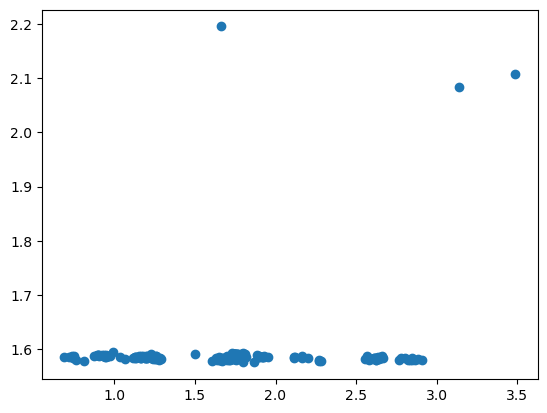

In [ ]:
plt.scatter(all_targets, all_preds)